In [ ]:
#Libraries

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.io as pio
import statsmodels.api as sm
import json
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from transformers import pipeline
from sklearn.preprocessing import MinMaxScaler

In [ ]:
# Load your dataset

df = pd.read_csv('/content/best_buy_products_filtered.csv')


In [ ]:
df.head()

,url,product_id,title,images,final_price,currency,discount,initial_price,offer_price,root_category,...,features,whats_included,q_a,product_specifications,amount_of_stars,customer_images,customers_ultimately_bought,deals_on_realated_items,frequently_bought_with,recommend_percentage
0,https://www.bestbuy.com/site/instant-pot-preci...,6488565,Instant Pot - Precision 5-in-1 Electric Dutch ...,https://pisces.bbystatic.com/image2/BestBuy_US...,$229.99,USD,NaN,$229.99,$57.50,Appliances,...,"Braise, slow cooking, sear\u002Fsauté, cooking...",NaN,"[{""answer"":""We appreciate your questions. The ...","[{""specification_name"":""Product Name"",""specifi...","[{""2_stars"":""1"",""3_stars"":""2"",""4_stars"":""2"",""5...",https://pisces.bbystatic.com/image2/BestBuy_US...,NaN,"Dutch Ovens deals,Outlet Deals,Top Deals",NaN,89.0
1,https://www.bestbuy.com/site/instant-pot-vorte...,6367858,Instant Pot - Vortex Plus 10 Quart Air Fryer O...,https://pisces.bbystatic.com/image2/BestBuy_US...,$149.99,USD,NaN,$149.99,$37.50,Appliances,...,"Air fry, broil, bake, roast, dehydrate, reheat...","Instant Vortex Plus 7-in-1,Drip tray,2 x cooki...","[{""answer"":""You can use any ovenproof dish or ...","[{""specification_name"":""Non-Stick Interior"",""s...","[{""1_star"":""31"",""2_stars"":""34"",""3_stars"":""52"",...",https://pisces.bbystatic.com/image2/BestBuy_US...,NaN,"Air Fryers deals,Outlet Deals,Top Deals",NaN,89.0
2,https://www.bestbuy.com/site/instant-sports-su...,6424665,Instant Sports Summer Games - Nintendo Switch ...,https://pisces.bbystatic.com/image2/BestBuy_US...,$24.99,USD,NaN,$24.99,NaN,Video Games,...,"Relay race, high jump, javelin throw, triple j...",Instant Sports Summer Games,NaN,"[{""specification_name"":""ESRB Rating"",""specific...","[{""1_star"":""1"",""2_stars"":""1"",""3_stars"":""1"",""4_...",NaN,"[{""currency"":""USD"",""final_price"":""$39.99"",""ini...","Game Downloads deals,Video Games Outlet Deals,...","[{""currency"":""USD"",""final_price"":""49.99"",""revi...",43.0
3,https://www.bestbuy.com/site/insurgency-sandst...,6474765,"Insurgency Sandstorm - Xbox One, Xbox Series S...",https://pisces.bbystatic.com/image2/BestBuy_US...,$27.99,USD,Save $12,$39.99,NaN,Video Games,...,Team up in intense 8-player co-operative gamep...,NaN,"[{""answer"":""yes it has solo mode for Insurgenc...","[{""specification_name"":""ESRB Rating"",""specific...","[{""1_star"":""5"",""2_stars"":""2"",""3_stars"":""4"",""4_...",https:\u002F\u002Fpisces.bbystatic.com\u002Fim...,"[{""currency"":""USD"",""final_price"":""$49.99"",""ini...","Physical Video Games deals,Video Games Outlet ...","[{""currency"":""USD"",""final_price"":""29.99"",""revi...",80.0
4,https://www.bestbuy.com/site/intel-core-i5-124...,6492599,Intel - Core i5-12400 12th Generation - 6 Core...,https://pisces.bbystatic.com/image2/BestBuy_US...,$169.99,USD,Save $40,$209.99,$42.50,Computers & Tablets,...,"[""12th Gen Intel Core desktop processors are o...",Core i5-12400 12th Generation - 6 Core - 12 Th...,NaN,NaN,"[{""1_star"":""1"",""4_stars"":""3"",""5_stars"":""29""}]",https://pisces.bbystatic.com/image2/BestBuy_US...,NaN,"CPUs / Processors deals,Outlet Deals,Top Deals",NaN,97.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 34 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   url                          1000 non-null   object 
 1   product_id                   1000 non-null   int64  
 2   title                        1000 non-null   object 
 3   images                       998 non-null    object 
 4   final_price                  1000 non-null   object 
 5   currency                     1000 non-null   object 
 6   discount                     263 non-null    object 
 7   initial_price                1000 non-null   object 
 8   offer_price                  690 non-null    object 
 9   root_category                1000 non-null   object 
 10  breadcrumbs                  1000 non-null   object 
 11  release_date                 116 non-null    object 
 12  esrb_rating                  61 non-null     object 
 13  rating             

In [ ]:
print(df.columns, len(df.columns))

Index(['url', 'product_id', 'title', 'images', 'final_price', 'currency',
       'discount', 'initial_price', 'offer_price', 'root_category',
       'breadcrumbs', 'release_date', 'esrb_rating', 'rating', 'reviews_count',
       'questions_count', 'hot_offer', 'open_box', 'availability',
       'you_maight_also_need', 'variations', 'highlights',
       'product_description', 'features_summary', 'features', 'whats_included',
       'q_a', 'product_specifications', 'amount_of_stars', 'customer_images',
       'customers_ultimately_bought', 'deals_on_realated_items',
       'frequently_bought_with', 'recommend_percentage'],
      dtype='object') 34


In [ ]:
# Cleaning the prices
df['final_price'] = df['final_price'].replace(r'[\$,]', '', regex=True).astype(float)
df['initial_price'] = df['initial_price'].replace(r'[\$,]', '', regex=True).astype(float)

In [ ]:
# Filling missing 'release_date' with median date
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
median_date = df['release_date'].median()

# Filling the column with the median date
df['release_date'] = df['release_date'].fillna(median_date)


In [ ]:
# Fill numeric missing values with median
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

In [ ]:
# Fill categorical missing values with mode
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


In [ ]:
# Fetching year from the date column
df['year'] = df['release_date'].dt.year

In [ ]:
df['final_price'][0]

np.float64(229.99)

In [ ]:

# Suppose you want 10 bins for final_price
bins = [0, 50, 100, 200, 300, 400, 500, 1000, 2000, 5000, 10000, df['final_price'].max() + 1]


# Create a binned column for final_price
df['price_bin'] = pd.cut(df['final_price'], bins=bins, include_lowest=True, right=False)


# Count how many products fall into each price bin
price_bin_counts = df['price_bin'].value_counts().sort_index()


# Build the bar chart in Plotly
fig = px.bar(
    x=price_bin_counts.index.astype(str),
    y=price_bin_counts.values,
    title='Number of Products by Final Price Range',

    labels={'x': 'Final Price Range', 'y': 'Number of Products'},
    height=700,
    width=1400
)


# Rotate the x-axis labels and set y-axis limit to 450
fig.update_layout(
    xaxis=dict(tick0=3, dtick=0.15, tickangle=0),
    yaxis=dict(range=[0, 450]),
)



fig.show()

In [ ]:
# Rating Distribution
fig = px.histogram(df, x='rating', nbins=20,
                   title='Univariate Analysis: Rating Distribution',
                   labels={'rating': 'Customer Ratings'},color='root_category',height=600, width = 600)

fig.update_yaxes(range=[0, 500], dtick=25)
fig.update_xaxes(dtick=0.5)
fig.show()


In [ ]:
## Discount Percentage Distribution  #HAS TO FIX IT
#it contains columns like save 50,....

fig = px.histogram(df, x='discount', nbins=30,
                   title='Distribution of Discount Percentages',color='root_category')
fig.update_layout(xaxis_title='Discount Percentage', yaxis_title='Frequency')
fig.show()


In [ ]:
df['discount_percentage'] = ((df['initial_price'] - df['final_price']) / df['initial_price']) * 100

In [ ]:

# Category distrubution
category_dist = df['root_category'].value_counts()
print("Top 10 Product Categories:")
print(category_dist.head(10))


# Visualization for category distribution
fig = px.bar(
    x=category_dist.head(10).index,
    y=category_dist.head(10).values,
    title='Top 10 Product Categories',
    labels={'x': 'Category', 'y': 'Count'},
    text=category_dist.head(10).values
)


fig.update_layout(xaxis_title='Category', yaxis_title='Count')

fig.show()

Top 10 Product Categories:
root_category
Appliances                  246
Car Electronics & GPS       195
Video Games                 115
Computers & Tablets         112
Smart Home                   55
Cell Phones                  42
TV & Home Theater            35
Gift Cards                   34
Home, Furniture & Office     33
Audio                        31
Name: count, dtype: int64


In [ ]:
# Data preprocessing for the discount column
df['discount_range'] = df['discount'].replace(r'\D', '', regex=True).astype(float)

In [ ]:
df['discount_range'].head()

,discount_range
0,50.0
1,50.0
2,50.0
3,12.0
4,40.0


In [ ]:
## veryyy minor change
fig = px.histogram(df, x='discount_percentage',
                   title='Distribution of Discount Ranges',
                   labels={'discount_range': 'Discount Range (%)'},range_x=[0, 40,],color='root_category', height = 400, width = 700)
fig.show()

In [ ]:
df.columns

Index(['url', 'product_id', 'title', 'images', 'final_price', 'currency',
       'discount', 'initial_price', 'offer_price', 'root_category',
       'breadcrumbs', 'release_date', 'esrb_rating', 'rating', 'reviews_count',
       'questions_count', 'hot_offer', 'open_box', 'availability',
       'you_maight_also_need', 'variations', 'highlights',
       'product_description', 'features_summary', 'features', 'whats_included',
       'q_a', 'product_specifications', 'amount_of_stars', 'customer_images',
       'customers_ultimately_bought', 'deals_on_realated_items',
       'frequently_bought_with', 'recommend_percentage', 'year', 'price_bin',
       'discount_percentage', 'discount_range'],
      dtype='object')

In [ ]:
df['recommend_percentage'].head()

,recommend_percentage
0,89.0
1,89.0
2,43.0
3,80.0
4,97.0


In [ ]:
df['availability'].head()

,availability
0,"[{""availability_name"":""Pickup""},{""availability..."
1,"[{""availability_name"":""Pickup"",""availability_v..."
2,"[{""availability_name"":""Pickup"",""availability_v..."
3,"[{""availability_name"":""Pickup"",""availability_v..."
4,"[{""availability_name"":""Pickup"",""availability_v..."


In [ ]:
#availability column
df['availability'][1]

'[{"availability_name":"Pickup","availability_value":"2024-05-02T00:00:00.000Z"},{"availability_name":"Shipping","availability_value":"2024-04-30T00:00:00.000Z"}]'

In [ ]:
# Function to safely parse JSON-like strings and extract availability types

def extract_availability_types(availability_json):
    availability_types = []
    if pd.isna(availability_json):
        return availability_types
    try:
        # Convert single quotes to double quotes and parse the string as JSON
        availability_list = json.loads(availability_json.replace("'", '"'))
        for item in availability_list:
            if 'availability_name' in item:
                availability_types.append(item['availability_name'])
    except Exception as e:
        print(f"Error parsing JSON: {e} - JSON: {availability_json}")
    return availability_types

# Apply the function to the availability column
df['availability_types'] = df['availability'].apply(extract_availability_types)

# Explode the list into separate rows
df_exploded = df.explode('availability_types')

In [ ]:
# Checking if the extraction went well
print(df_exploded['availability_types'].value_counts())

# Count the occurrence of each availability type
availability_counts = df_exploded['availability_types'].value_counts().reset_index()
availability_counts.columns = ['Availability', 'Count']

# Creating the bar plot with Plotly
import plotly.express as px

if not availability_counts.empty:
    fig = px.bar(availability_counts, x='Availability', y='Count', title='Product Availability Types', height = 400, width = 700)
    fig.show()
else:
    print("No data available to plot.")

availability_types
Pickup                     978
Shipping                   858
Delivery                    73
Delivery + Installation     64
Name: count, dtype: int64


In [ ]:
df['esrb_rating'].head()

,esrb_rating
0,M (Mature 17+)
1,M (Mature 17+)
2,E (Everyone)
3,M (Mature 17+)
4,M (Mature 17+)


In [ ]:
# Visualization of ESRB Rating Distribution
fig = px.histogram(df, x='esrb_rating', title='ESRB Rating Distribution',color='root_category', height = 600, width = 600)
fig.show()

In [ ]:
# Product Recommendation Percentage Distribution
fig = px.histogram(df, x='recommend_percentage', color='root_category',title='Distribution of Recommendation Percentages', width = 800, height = 400)
fig.show()

## Bi-Variate Analysis

In [ ]:
#Final price vs rating
filtered_data = df[df['final_price'] <= 1000]
fig = px.scatter(filtered_data, x='final_price', y='rating',
                 title='Final Price vs Rating (Products with price ≤ $1000)',
                 color='root_category',
                 labels={'final_price': 'Final Price ($)', 'rating': 'Rating'},
                 height = 500,
                 width = 800)
fig.show()

In [ ]:
#Reviews Count vs Rating

# Filtering extreme outliers for clarity
df_filtered = df[df['reviews_count'] <= df['reviews_count'].quantile(0.98)]

fig = px.scatter(df_filtered,
                 x='rating',
                 y='reviews_count',
                 title='Bivariate Analysis: Rating vs Reviews Count (Filtered)',
                 labels={'rating':'Average Rating', 'reviews_count':'Number of Reviews'},
                 hover_data=['title'],
                 color='root_category',
                 width=800,
                 height=600
                )

# Optimized axes limits for clarity
fig.update_xaxes(range=[0, 5], dtick=0.25)
fig.update_yaxes(range=[0, df_filtered['reviews_count'].max()+500], dtick=500)


fig.show()

In [ ]:
#Price Distribution by Root Category
fig = px.box(df, x='root_category', y='final_price',
             title='Price Distribution by Root Category',
             labels={'root_category': 'Root Category', 'final_price': 'Final Price ($)'},
             notched=True,
             width = 800,
             height = 600)
fig.update_traces(quartilemethod="inclusive")
fig.show()

In [ ]:
df['year'].max()

2024

In [ ]:
fig = px.scatter(df, x='reviews_count', y='questions_count', trendline='ols',
                 title='Reviews Count vs. Questions Count', height=400, width=600)
fig.update_layout(xaxis_title='Reviews Count', yaxis_title='Questions Count')
fig.show()

In [ ]:
df['reviews_count'].head()

,reviews_count
0,27.0
1,941.0
2,7.0
3,40.0
4,33.0


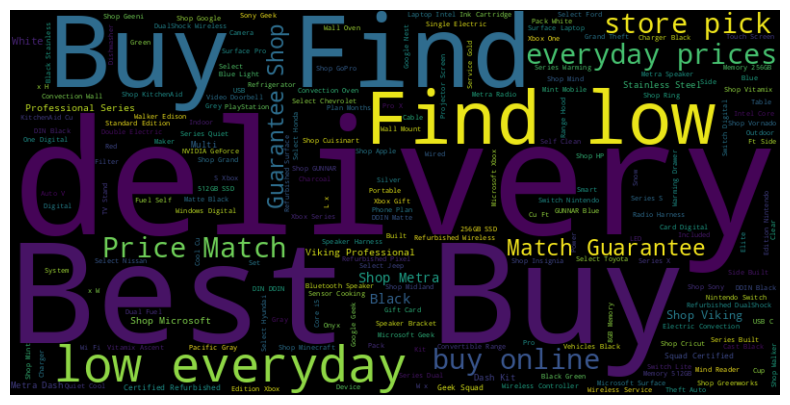

In [ ]:
#!pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = ' '.join(df['product_description'].dropna())
wordcloud = WordCloud(width=800, height=400).generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [ ]:
import plotly.graph_objects as go
numeric_cols = ['final_price', 'initial_price', 'rating', 'reviews_count', 'questions_count', 'recommend_percentage']
corr_matrix = df[numeric_cols].corr()

fig = go.Figure(data=go.Heatmap(
    z=corr_matrix,
    x=corr_matrix.columns,
    y=corr_matrix.columns,
    colorscale='Blues'
))
fig.update_layout(title='Correlation Matrix of Numeric Variables')
fig.update_layout(autosize=False, width=800, height=600)

fig.show()

In [ ]:
df['year'] = pd.to_datetime(df['release_date']).dt.year
fig = px.histogram(df, x='year',
                   title='Product Releases Over the Years',
                   labels={'year': 'Year'},color='root_category', width=800, height=400)
fig.update_layout(xaxis_title='Year', yaxis_title='Number of Products Released')
fig.show()

In [ ]:
fig = px.scatter_matrix(df,
                        dimensions=['reviews_count', 'questions_count', 'rating', 'final_price'],
                        color='root_category',
                        title='Impact of Reviews, Questions, and Ratings on Price')

fig.update_layout(autosize=False, width=1200, height=800)
fig.show()

In [ ]:
df['discount_percentage'].head()

,discount_percentage
0,0.000000
1,0.000000
2,0.000000
3,30.007502
4,19.048526


In [ ]:
# Assuming 'release_date' is converted to datetime
df['month'] = pd.to_datetime(df['release_date']).dt.month

fig = px.line(df.groupby('month').size(), title='Seasonal Trends in Product Releases',
              labels={'value': 'Number of Products', 'month': 'Month'}, width=600, height=400)
fig.show()

In [ ]:
# Yearly Average Rating Trends
yearly_average_rating = df.groupby('year')['rating'].mean()
fig = px.line(yearly_average_rating, title='Yearly Average Rating Trends', labels={'year': 'Year', 'rating': 'Average Rating'}, width=600, height=400)
fig.show()

In [ ]:
df.head()

,url,product_id,title,images,final_price,currency,discount,initial_price,offer_price,root_category,...,customers_ultimately_bought,deals_on_realated_items,frequently_bought_with,recommend_percentage,year,price_bin,discount_percentage,discount_range,availability_types,month
0,https://www.bestbuy.com/site/instant-pot-preci...,6488565,Instant Pot - Precision 5-in-1 Electric Dutch ...,https://pisces.bbystatic.com/image2/BestBuy_US...,229.99,USD,Save $50,229.99,$57.50,Appliances,...,"[{""currency"":""USD"",""final_price"":""$0.00"",""init...","Dutch Ovens deals,Outlet Deals,Top Deals","[{""currency"":""USD"",""final_price"":""100"",""review...",89.0,2019,"[200.0, 300.0)",0.000000,50.0,"[Pickup, Shipping]",12
1,https://www.bestbuy.com/site/instant-pot-vorte...,6367858,Instant Pot - Vortex Plus 10 Quart Air Fryer O...,https://pisces.bbystatic.com/image2/BestBuy_US...,149.99,USD,Save $50,149.99,$37.50,Appliances,...,"[{""currency"":""USD"",""final_price"":""$0.00"",""init...","Air Fryers deals,Outlet Deals,Top Deals","[{""currency"":""USD"",""final_price"":""100"",""review...",89.0,2019,"[100.0, 200.0)",0.000000,50.0,"[Pickup, Shipping]",12
2,https://www.bestbuy.com/site/instant-sports-su...,6424665,Instant Sports Summer Games - Nintendo Switch ...,https://pisces.bbystatic.com/image2/BestBuy_US...,24.99,USD,Save $50,24.99,$12.50,Video Games,...,"[{""currency"":""USD"",""final_price"":""$39.99"",""ini...","Game Downloads deals,Video Games Outlet Deals,...","[{""currency"":""USD"",""final_price"":""49.99"",""revi...",43.0,2020,"[0.0, 50.0)",0.000000,50.0,"[Pickup, Shipping]",8
3,https://www.bestbuy.com/site/insurgency-sandst...,6474765,"Insurgency Sandstorm - Xbox One, Xbox Series S...",https://pisces.bbystatic.com/image2/BestBuy_US...,27.99,USD,Save $12,39.99,$12.50,Video Games,...,"[{""currency"":""USD"",""final_price"":""$49.99"",""ini...","Physical Video Games deals,Video Games Outlet ...","[{""currency"":""USD"",""final_price"":""29.99"",""revi...",80.0,2021,"[0.0, 50.0)",30.007502,12.0,"[Pickup, Shipping]",9
4,https://www.bestbuy.com/site/intel-core-i5-124...,6492599,Intel - Core i5-12400 12th Generation - 6 Core...,https://pisces.bbystatic.com/image2/BestBuy_US...,169.99,USD,Save $40,209.99,$42.50,Computers & Tablets,...,"[{""currency"":""USD"",""final_price"":""$0.00"",""init...","CPUs / Processors deals,Outlet Deals,Top Deals","[{""currency"":""USD"",""final_price"":""100"",""review...",97.0,2019,"[100.0, 200.0)",19.048526,40.0,"[Pickup, Shipping]",12


In [ ]:
# Convert index to datetime
df.index = pd.to_datetime(df.index, errors='coerce')

# Drop invalid dates
df = df[~df.index.isna()]

# Monthly product counts
monthly_data = df.set_index('release_date').resample('ME').size()

# Fit ARIMA model
model = sm.tsa.statespace.SARIMAX(
    monthly_data,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12)
)

results = model.fit()

# Forecast next 12 months
forecast = results.get_forecast(steps=12)
print(forecast.summary_frame())

y                               mean    mean_se  mean_ci_lower  mean_ci_upper
2024-05-31 00:00:00+00:00   2.533633  78.600582    -151.520677     156.587943
2024-06-30 00:00:00+00:00   2.627367  78.619005    -151.463050     156.717784
2024-07-31 00:00:00+00:00   3.454840  78.494737    -150.392017     157.301697
2024-08-31 00:00:00+00:00   3.372313  78.515269    -150.514787     157.259413
2024-09-30 00:00:00+00:00   4.625360  78.535748    -149.301877     158.552597
2024-10-31 00:00:00+00:00   4.215802  78.556220    -149.751561     158.183165
2024-11-30 00:00:00+00:00   4.042555  78.576688    -149.964923     158.050033
2024-12-31 00:00:00+00:00  77.898243  78.597150     -76.149340     231.945827
2025-01-31 00:00:00+00:00   3.067686  78.617607    -151.019992     157.155363
2025-02-28 00:00:00+00:00   3.515308  78.638058    -150.612453     157.643070
2025-03-31 00:00:00+00:00   3.949885  78.658505    -150.217951     158.117722
2025-04-30 00:00:00+00:00   3.443573  78.679034    -150.764499  

In [ ]:
# Assuming 'forecast' is your ARIMA model forecast output
forecast_df = forecast.summary_frame()

fig = go.Figure()

# Plotting the mean forecast
fig.add_trace(go.Scatter(
    x=forecast_df.index,
    y=forecast_df['mean'],
    mode='lines',
    name='Forecasted Mean'
))

# Adding upper and lower confidence intervals
fig.add_trace(go.Scatter(
    x=forecast_df.index.tolist() + forecast_df.index[::-1].tolist(),
    y=forecast_df['mean_ci_upper'].tolist() + forecast_df['mean_ci_lower'][::-1].tolist(),
    fill='toself',
    fillcolor='rgba(0,100,80,0.2)',
    line=dict(color='rgba(255,255,255,0)'),
    name='Confidence Interval'
))

fig.update_layout(
    title='ARIMA Forecast with Confidence Intervals',
    xaxis_title='Date',
    yaxis_title='Forecasted Value',
    showlegend=True
)

fig.show()
pio.write_html(fig, file='gg.html', auto_open=True)

In [ ]:
df['discount_percentage'] = df['discount_percentage'].fillna(df['discount_percentage'].median())

In [ ]:
# Predictive Analytics: Predicting Recommendation Percentage
X = df[['final_price', 'rating', 'reviews_count', 'questions_count','discount_percentage']]
y = df['recommend_percentage']
X = add_constant(X)  # adding a constant

# Fit model
model = OLS(y, X).fit()
print(model.summary())

# Visualize the relationship
fig = px.scatter(df, x='rating', y='recommend_percentage', trendline='ols', title='Rating vs. Recommendation Percentage')
fig.show()

                             OLS Regression Results                             
Dep. Variable:     recommend_percentage   R-squared:                       0.580
Model:                              OLS   Adj. R-squared:                  0.578
Method:                   Least Squares   F-statistic:                     274.3
Date:                  Wed, 29 Apr 2026   Prob (F-statistic):          2.76e-184
Time:                          00:51:32   Log-Likelihood:                -3576.5
No. Observations:                  1000   AIC:                             7165.
Df Residuals:                       994   BIC:                             7194.
Df Model:                             5                                         
Covariance Type:              nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const         

In [ ]:
#Address Multicollinearity check ,if they are greater than 10,then issue

# Function to calculate VIF for each feature
def calculate_vif(df, features):
    X = df[features].copy()
    X['Intercept'] = 1

    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    return vif_data.drop(index=vif_data[vif_data['feature'] == 'Intercept'].index)

# Calculate VIF for your model's features
features = ['final_price', 'rating', 'reviews_count', 'questions_count', 'discount_percentage']
vif_data = calculate_vif(df, features)
print(vif_data)

               feature       VIF
0          final_price  1.039173
1               rating  1.029226
2        reviews_count  1.394782
3      questions_count  1.379601
4  discount_percentage  1.033240


In [ ]:
X = df[['final_price', 'rating', 'reviews_count', 'questions_count', 'discount_percentage']]
y = df['recommend_percentage']

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# OLS Regression
ols_model = LinearRegression()
ols_model.fit(X_train, y_train)
y_pred_ols = ols_model.predict(X_test)
r2_ols = r2_score(y_test, y_pred_ols)
print(f"OLS R-squared: {r2_ols}")

OLS R-squared: 0.7664876256809


In [ ]:
# Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)
r2_ridge = r2_score(y_test, y_pred_ridge)
print(f"Ridge R-squared: {r2_ridge}")

Ridge R-squared: 0.7650593850651504


In [ ]:
# Lasso Regression
lasso_model = Lasso(alpha=0.01)  # Alpha is a hyperparameter and should be chosen wisely
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)
r2_lasso = r2_score(y_test, y_pred_lasso)
print(f"Lasso R-squared: {r2_lasso}")

Lasso R-squared: 0.7658200836412005


In [ ]:
# Comparing the models
print("Comparison of Models:")
print(f"OLS Model R-squared: {r2_ols}")
print(f"Ridge Model R-squared: {r2_ridge}")
print(f"Lasso Model R-squared: {r2_lasso}")

Comparison of Models:
OLS Model R-squared: 0.7664876256809
Ridge Model R-squared: 0.7650593850651504
Lasso Model R-squared: 0.7658200836412005


In [ ]:
# You may also want to check other metrics like Mean Squared Error
mse_ols = mean_squared_error(y_test, y_pred_ols)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
print(f"OLS MSE: {mse_ols}")
print(f"Ridge MSE: {mse_ridge}")
print(f"Lasso MSE: {mse_lasso}")

OLS MSE: 42.5349269790628
Ridge MSE: 42.79508497058932
Lasso MSE: 42.65652161402324


In [ ]:
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

# Define sentiment labels
sentiment_labels = ['Positive', 'Neutral', 'Negative']

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

In [ ]:
# Function to classify sentiment of descriptions
def classify_sentiment(text):
    if pd.isna(text):
        return "No Description"  # Handle missing descriptions
    result = classifier(text, candidate_labels=sentiment_labels, multi_label=False)
    return result['labels'][0]  # Return the highest scoring sentiment

# Apply the classification to each product description
df['sentiment'] = df['product_description'].apply(classify_sentiment)

# Optionally, calculate the proportion of each sentiment
sentiment_distribution = df['sentiment'].value_counts(normalize=True)
print("Sentiment Distribution in Product Descriptions:")
print(sentiment_distribution)

Sentiment Distribution in Product Descriptions:
sentiment
Positive    0.988
Negative    0.008
Neutral     0.004
Name: proportion, dtype: float64


In [ ]:
# Display some results
print(df[['product_description', 'sentiment']].head())

                                                             product_description  \
1970-01-01 00:00:00.000000000  Shop Instant Pot Precision 5-in-1 Electric Dut...   
1970-01-01 00:00:00.000000001  Shop Instant Pot Vortex Plus 10 Quart Air Frye...   
1970-01-01 00:00:00.000000002  Shop Instant Sports Summer Games Nintendo Swit...   
1970-01-01 00:00:00.000000003  Shop Insurgency Sandstorm Xbox One, Xbox Serie...   
1970-01-01 00:00:00.000000004  Shop Intel Core i5-12400 12th Generation 6 Cor...   

                              sentiment  
1970-01-01 00:00:00.000000000  Positive  
1970-01-01 00:00:00.000000001  Positive  
1970-01-01 00:00:00.000000002  Positive  
1970-01-01 00:00:00.000000003  Positive  
1970-01-01 00:00:00.000000004  Positive  


In [ ]:
df.to_csv('final_best_buy_data.csv', index=False)

In [ ]:
# Create a Treemap to visualize sentiment distribution across root categories
fig = px.treemap(df, path=['root_category', 'sentiment'], values='product_id',
                 title='Treemap of Product Sentiment by Category',
                  color_discrete_map={'Positive': 'green', 'Neutral': 'gray', 'Negative': 'red'})

fig.update_layout(margin=dict(t=0, l=0, r=0, b=0))  # Adjust layout to use space efficiently
fig.show()

In [ ]:
# Mapping from category and sentiment to integers for plotting
label_list = df['root_category'].unique().tolist() + ['Positive', 'Negative', 'Neutral']
label_dict = {label: idx for idx, label in enumerate(label_list)}

# Creating source, target, and value lists
source = []
target = []
value = []
colors = []

for index, row in df.iterrows():
    source.append(label_dict[row['root_category']])
    target.append(label_dict[row['sentiment']])
    value.append(1)  # or use actual numbers if you have counts of sentiments per category
    if row['sentiment'] == 'Positive':
        colors.append('rgba(76, 175, 80, 0.6)')
    elif row['sentiment'] == 'Negative':
        colors.append('rgba(244, 67, 54, 0.6)')
    else:
        colors.append('rgba(158, 158, 158, 0.6)')

# Creating the Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
      pad=15,
      thickness=20,
      line=dict(color="black", width=0.5),
      label=label_list,
      color=["blue"] * len(df['root_category'].unique()) + ["green", "red", "grey"]
    ),
    link=dict(
      source=source,  # indices correspond to labels, eg A1, A2, A1, B1, ...
      target=target,
      value=value,
      color=colors
    ))])

fig.update_layout(title_text="Sankey Diagram of Sentiments by Product Category", font_size=10)
fig.show()

In [ ]:
# Creating the bubble chart
fig = px.scatter(df,
                 x='rating',
                 y='reviews_count',
                 size='recommend_percentage',
                 color='sentiment',
                 hover_name='title',  # Assuming you have a title column for product names
                 size_max=60,
                 title="Interactive Bubble Chart: Rating vs Reviews Count",
                 labels={
                     "rating": "Rating",
                     "reviews_count": "Reviews Count",
                     "recommend_percentage": "Recommendation Percentage"
                 },
                 color_discrete_map={
                     "Positive": "green",
                     "Negative": "red",
                     "Neutral": "grey"
                 })

# Adjust the layout for better presentation
fig.update_layout(xaxis_title='Rating',
                  yaxis_title='Reviews Count',
                  legend_title_text='Sentiment')

fig.show()

In [ ]:
yearly_avg_price = df.groupby('year')['final_price'].mean().reset_index()
fig11 = px.line(yearly_avg_price, x='year', y='final_price', markers=True,
                title='Yearly Average Final Price Trends',
                labels={'year': 'Year', 'final_price': 'Average Final Price ($)'})
fig11.update_layout(xaxis=dict(tickmode='linear'))
fig11.show()

In [ ]:
# Advanced Visualization: Sunburst Plot
fig = px.sunburst(df, path=['root_category', 'year', 'esrb_rating'], values='reviews_count', title='Sunburst: Categories by Year and Rating')
fig.show()

In [ ]:
fig = px.parallel_coordinates(df,
                              dimensions=['final_price', 'rating', 'reviews_count', 'questions_count', 'recommend_percentage'],
                              color='rating',
                              color_continuous_scale=px.colors.sequential.RdBu,  # Corrected color scale
                              title='Enhanced Parallel Coordinates of Key Metrics')

fig.update_layout(margin=dict(t=50, l=50, r=50, b=50))
fig.show()

In [ ]:
# Normalize key numerical columns for better visualization
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[['final_price', 'rating', 'reviews_count', 'questions_count', 'recommend_percentage']] = scaler.fit_transform(
    df[['final_price', 'rating', 'reviews_count', 'questions_count', 'recommend_percentage']])


# Aggregate metrics by root_category
category_stats = df.groupby('root_category')[['final_price', 'rating', 'reviews_count', 'questions_count', 'recommend_percentage']].mean().reset_index()

# Normalize data
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(category_stats.iloc[:, 1:])
normalized_df = pd.DataFrame(normalized_data, columns=['final_price', 'rating', 'reviews_count', 'questions_count', 'recommend_percentage'])

# Radar Plot
fig = go.Figure()

for i in range(len(category_stats)):
    fig.add_trace(go.Scatterpolar(
        r=normalized_df.iloc[i].values,
        theta=['final_price', 'rating', 'reviews_count', 'questions_count', 'recommend_percentage'],
        fill='toself',
        name=category_stats['root_category'][i]
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True)),
    title='Radar Plot of Average Metrics by Category'
)
fig.show()

In [ ]:
sentiment_counts = df.groupby(['root_category', 'sentiment']).size().reset_index(name='count')

fig = px.scatter_polar(sentiment_counts, r='count', theta='root_category',
                       color='sentiment', size='count',
                       title='Polar Area Plot: Sentiment Distribution by Category')
fig.show()